In [1]:
import requests
from bs4 import BeautifulSoup
import re
from oceanobs.weather_warnings.weather_warning_chm import WeatherWarningCHM
import geopandas as gpd
import xml.etree.ElementTree as ET
from oceanobs.weather_stations.metar import MetarStations
from oceanobs.weather_stations.inmet import Inmet
from oceanobs.gts.ship_observations import ShipObservations

import json

%load_ext autoreload
%autoreload 2

In [2]:
from oceanobs.water_quality.sp import WaterQualitySP

In [4]:
c = WaterQualitySP()
stations = c.get_stations()
stations

,name,identifier,latitude,longitude,geometry
0,UBATUBA - PICINGUABA,UBPC017,-23.378114,-44.838033,POINT (-4991347.039 -2677809.615)
1,UBATUBA - LAGOA PRUMIRIM,UBLP039,-23.378733,-44.955781,POINT (-5004454.6 -2677884.739)
2,UBATUBA - PRAIA DO PRUMIRIM,UBPR040,-23.379194,-44.957472,POINT (-5004642.915 -2677940.66)
3,UBATUBA - FÉLIX,UBFX042,-23.389161,-44.971728,POINT (-5006229.836 -2679149.428)
4,UBATUBA - ITAMAMBUCA,UBIM047,-23.402250,-45.003444,POINT (-5009760.519 -2680736.999)
...,...,...,...,...,...
170,IGUAPE - JUREIA,IGJU528,-24.654083,-47.384300,POINT (-5274796.148 -2833315.995)
171,ILHA COMPRIDA - BALNEÁRIO ADRIANA,ICBA550,-24.736933,-47.529725,POINT (-5290984.785 -2843467.239)
172,ILHA COMPRIDA - CENTRO,ICCE552,-24.749825,-47.551886,POINT (-5293451.748 -2845047.405)
173,ILHA COMPRIDA - PONTAL (LADO OCEANO),ICPO600,-25.028758,-47.883194,POINT (-5330332.823 -2879277.351)


In [38]:
data = c.get()

In [56]:
from oceanobs.water_quality.sc import WaterQualitySC

In [59]:
c = WaterQualitySC()
stations = c.get_stations()
stations.head()

,identifier,name,latitude,longitude,geometry
0,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,-27.61293287423,-48.54752607809,POINT (-5404285.882 -3200260.548)
1,331,GOVERNADOR CELSO RAMOS - Ponto 11 - PRAIA DE P...,-27.3343682394682,-48.531632986608,POINT (-5402516.671 -3165309.112)
2,215,FLORIANÓPOLIS - Ponto 01 - PRAIA DO JARDIM ATL...,-27.5738221075775,-48.5973044209087,POINT (-5409827.182 -3195347.988)
3,315,BALNEÁRIO GAIVOTA - Ponto 02 - ARROIO DA PRAI...,-29.157521,-49.573059,POINT (-5518447.685 -3395710.246)
4,316,FLORIANÓPOLIS - Ponto 69 - PRAIA BRAVA,-27.4059159062729,-48.4113937567057,POINT (-5389131.702 -3174277.757)


In [60]:
data = c.get()
data.head()

,identifier,name,date_time,cleaning
0,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,2025-03-25,False
1,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,2025-03-18,False
2,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,2025-03-11,False
3,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,2025-03-06,False
4,272,FLORIANÓPOLIS - Ponto 52 - PRAIA DO JOSÉ MENDES,2025-02-25,False


In [ ]:
data = c.get()

In [41]:
data.head()

,date_time,name,cleaning
0,2025-03-01 03:00:00,UBATUBA - PICINGUABA,True
1,2025-03-01 03:00:00,UBATUBA - LAGOA PRUMIRIM,True
2,2025-03-01 03:00:00,UBATUBA - PRAIA DO PRUMIRIM,True
3,2025-03-01 03:00:00,UBATUBA - FÉLIX,True
4,2025-03-01 03:00:00,UBATUBA - ITAMAMBUCA,True


In [3]:
o = ShipObservations()

In [4]:
data = o.get()

In [5]:
data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2520 entries, 2 to 4912
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   station_type  2520 non-null   object             
 1   date_time     2520 non-null   datetime64[ns, UTC]
 2   latitude      2520 non-null   float64            
 3   longitude     2520 non-null   float64            
 4   wdir          829 non-null    Int64              
 5   wspd          829 non-null    float64            
 6   swvht         347 non-null    float64            
 7   tp            341 non-null    float64            
 8   pres          2520 non-null   float64            
 9   atmp          2402 non-null   float64            
 10  sst           717 non-null    float64            
 11  dewpt         2360 non-null   float64            
 12  swvht_swell   121 non-null    float64            
 13  wvdir_swell   134 non-null    float64            
 14  geome

In [68]:
i = Inmet()
stations = i.get_stations()

https://apimapas.inmet.gov.br/estacoes


In [54]:
stations

,identifier,name,latitude,longitude,geometry
0,S121,SANTA ISABEL DO RIO NEGRO,-0.414444,-65.017500,POINT (-7237714.993 -46136.097)
1,S115,PEF YAUARETE,0.599381,-69.191946,POINT (-7702412.196 66724.005)
2,S113,BALIZA,0.947942,-59.913180,POINT (-6669504.689 105529.235)
3,S114,PACARAIMA,4.477500,-61.149400,POINT (-6807120.07 498941.115)
4,S122,BONFIM,3.358889,-59.823889,POINT (-6659564.847 374124.155)
...,...,...,...,...,...
7520,D3260,ITATI - RESTAURANTE MIRADOR,-29.354870,-50.171900,POINT (-5585110.36 -3420891.036)
7521,D3265,LAGOA BONITA DO SUL - CENTRO,-29.490000,-53.013000,POINT (-5901380.165 -3438161.112)
7522,C891,CRIOSFERA,-84.000000,-79.494167,POINT (-8849250.154 -18807214.097)
7523,I891,COMANDANTE FERRAZ,-62.085278,-58.392500,POINT (-6500223.365 -8879391.935)


In [64]:
data = i.get_data(stations.iloc[3099])

In [65]:
data[0]

,atmp,pres,wspd,wdir,gust,date_time,name
0,25.2,959.6,0.7,263.0,2.9,2025-03-17 00:00:00,SALINAS
1,25.2,960.1,0.3,12.0,2.3,2025-03-17 01:00:00,SALINAS
2,24.3,960.5,0.3,8.0,1.6,2025-03-17 02:00:00,SALINAS
3,23.7,960.6,0.1,13.0,1.2,2025-03-17 03:00:00,SALINAS
4,23.5,960.6,0.4,327.0,2.1,2025-03-17 04:00:00,SALINAS
5,24.0,960.6,0.2,297.0,1.5,2025-03-17 05:00:00,SALINAS
6,23.8,960.3,0.3,33.0,1.0,2025-03-17 06:00:00,SALINAS
7,23.8,960.6,0.1,292.0,1.3,2025-03-17 07:00:00,SALINAS
8,23.0,960.9,0.8,267.0,1.3,2025-03-17 08:00:00,SALINAS
9,20.1,961.5,0.1,185.0,1.7,2025-03-17 09:00:00,SALINAS


In [2]:
i = Inmet(n_workers=12)
data = i.get()

S107
S122
S124
S121
S115
S111
S113
S123
S120
S125
S101
S114


S106


S110


S104


S102


...

D6125


D6124


D6123


D6115
D6114
D6113


Errors collecting data: ['Message: \nStacktrace:\n#0 0x575d8319f1fa <unknown>\n#1 0x575d82caf810 <unknown>\n#2 0x575d82cfe506 <unknown>\n#3 0x575d82cfe7a1 <unknown>\n#4 0x575d82d43c24 <unknown>\n#5 0x575d82d225ad <unknown>\n#6 0x575d82d41007 <unknown>\n#7 0x575d82d22323 <unknown>\n#8 0x575d82cf0de0 <unknown>\n#9 0x575d82cf1dbe <unknown>\n#10 0x575d8316b12b <unknown>\n#11 0x575d8316f0c7 <unknown>\n#12 0x575d831586cc <unknown>\n#13 0x575d8316fc47 <unknown>\n#14 0x575d8313d67f <unknown>\n#15 0x575d8318e288 <unknown>\n#16 0x575d8318e450 <unknown>\n#17 0x575d8319e076 <unknown>\n#18 0x798e71c9caa4 <unknown>\n#19 0x798e71d29c3c <unknown>\n', 'Message: \nStacktrace:\n#0 0x5bf78028c1fa <unknown>\n#1 0x5bf77fd9c810 <unknown>\n#2 0x5bf77fdeb506 <unknown>\n#3 0x5bf77fdeb7a1 <unknown>\n#4 0x5bf77fe30c24 <unknown>\n#5 0x5bf77fe0f5ad <unknown>\n#6 0x5bf77fe2e007 <unknown>\n#7 0x5bf77fe0f323 <unknown>\n#8 0x5bf77fdddde0 <unknown>\n#9 0x5bf77fddedbe <unknown>\n#10 0x5bf78025812b <unknown>\n#11 0x5bf780

In [4]:
data

,atmp,pres,wspd,wdir,gust,date_time,name
0,25.9,1007.4,0.0,253.0,0.0,2025-03-17 00:00:00,BARCELOS
1,25.8,1008.5,0.0,253.0,0.0,2025-03-17 01:00:00,BARCELOS
2,25.7,1009.3,0.0,253.0,0.0,2025-03-17 02:00:00,BARCELOS
3,25.5,1009.6,0.0,253.0,0.0,2025-03-17 03:00:00,BARCELOS
4,25.4,1009.3,0.0,253.0,0.0,2025-03-17 04:00:00,BARCELOS
...,...,...,...,...,...,...,...
576,23.8,988.2,0.4,135.0,1.2,2025-03-17 10:00:00,ARAGUACU
577,26.5,988.8,0.8,171.0,1.5,2025-03-17 11:00:00,ARAGUACU
578,28.4,989.1,1.5,227.0,2.8,2025-03-17 12:00:00,ARAGUACU
579,29.5,989.6,1.9,179.0,4.0,2025-03-17 13:00:00,ARAGUACU


In [58]:
data

Data  Hora Temperatura (°C)             Umidade (%)        \
   Unnamed: 0_level_1   UTC            Inst.  Máx.  Mín.       Inst.  Máx.   
0          17/03/2025     0             25.2  27.5  24.5        64.0  65.0   
1          17/03/2025   100             25.2  26.5  23.1        74.0  74.0   
2          17/03/2025   200             24.3  25.2  21.6        78.0  79.0   
3          17/03/2025   300             23.7  24.3  23.6        80.0  81.0   
4          17/03/2025   400             23.5  24.0  23.4        81.0  82.0   
5          17/03/2025   500             24.0  24.6  23.5        81.0  81.0   
6          17/03/2025   600             23.8  24.4  23.7        82.0  83.0   
7          17/03/2025   700             23.8  24.1  23.6        81.0  84.0   
8          17/03/2025   800             23.0  23.9  22.7        85.0  85.0   
9          17/03/2025   900             20.1  23.1  19.8        88.0  89.0   
10         17/03/2025  1000             22.7  22.7  20.0        79.0  89.0   
11         17/03/2025  1100             25.6  25.8  22.7        66.0  79.0   
12         17/03/2025  1200             28.3  28.5  25.4        56.0  68.0   
13         17/03/2025  1300             29.7  30.3  27.9        51.0  58.0   
14         17/03/2025  1400              NaN   NaN   NaN         NaN   NaN   
15         17/03/2025  1500              NaN   NaN   NaN         NaN   NaN   
16         17/03/2025  1600              NaN   NaN   NaN         NaN   NaN   
17         17/03/2025  1700              NaN   NaN   NaN         NaN   NaN   
18         17/03/2025  1800              NaN   NaN   NaN         NaN   NaN   
19         17/03/2025  1900              NaN   NaN   NaN         NaN   NaN   
20         17/03/2025  2000              NaN   NaN   NaN         NaN   NaN   
21         17/03/2025  2100              NaN   NaN   NaN         NaN   NaN   
22         17/03/2025  2200              NaN   NaN   NaN         NaN   NaN   
23         17/03/2025  2300              NaN   NaN   NaN         NaN   NaN   

         Pto. Orvalho (°C)             Pressão (hPa)                    Vento  \
    Mín.             Inst.  Máx.  Mín.         Inst.   Máx.   Mín. Vel. (m/s)   
0   51.0              17.8  19.1  15.6         959.6  959.6  958.2        0.7   
1   61.0              20.3  20.3  16.6         960.1  960.2  959.7        0.3   
2   74.0              20.1  20.2  17.6         960.5  960.5  960.1        0.3   
3   78.0              20.0  20.4  19.9         960.6  960.7  960.5        0.1   
4   79.0              19.9  20.4  19.8         960.6  960.7  960.5        0.4   
5   77.0              20.6  20.7  19.9         960.6  960.7  960.6        0.2   
6   79.0              20.5  20.9  20.4         960.3  960.6  960.3        0.3   
7   79.0              20.3  20.8  20.1         960.6  960.6  960.3        0.1   
8   79.0              20.3  20.4  19.8         960.9  960.9  960.6        0.8   
9   85.0              18.0  20.4  17.9         961.5  961.5  960.9        0.1   
10  79.0              18.8  19.0  18.0         962.0  962.0  961.5        0.5   
11  66.0              18.8  19.9  18.3         962.3  962.3  962.0        0.7   
12  55.0              18.7  20.1  18.0         962.2  962.3  962.1        0.8   
13  48.0              18.4  19.9  17.6         961.8  962.2  961.8        1.0   
14   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
15   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
16   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
17   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
18   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
19   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
20   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
21   NaN               NaN   NaN   NaN           NaN    NaN    NaN        NaN   
22   NaN               NaN   NaN   NaN      

In [55]:
stations[stations["identifier"] == "A552"]

,identifier,name,latitude,longitude,geometry
3099,A552,SALINAS,-16.160278,-42.310278,POINT (-4709958.577 -1823291.303)


In [27]:
from oceanobs.buoys.simcosta import Simcosta

s = Simcosta(n_workers=8)

In [45]:
m = MetarStations(n_workers=12)

In [46]:
stations = m.get_stations()

In [47]:
stations

,name,identifier,latitude,longitude,geometry
4016,UM CHRISTMAS/CASSID,PLCH,1.983333,-157.350000,POINT (-17516121.876 220827.762)
4017,UM FANNING ISLAND,PLFA,3.850000,-159.366667,POINT (-17740616.183 428902.924)
4018,UM PALMYRA/COOPER(A,PLPA,5.866667,-162.050000,POINT (-18039323.483 654218.512)
4020,UM JARVIS ISLAND (A,PLUR,-0.366667,-160.016667,POINT (-17812973.852 -40817.425)
4138,POINT SALINES,TGPY,12.000000,-61.783333,POINT (-6877689.206 1345708.408)
...,...,...,...,...,...
8636,MAUKE ISLAND,NCMK,-20.150000,-157.383333,POINT (-17519832.526 -2290808.978)
8637,MITIARO/NUKUROA,NCMR,-19.850000,-157.700000,POINT (-17555083.698 -2255269.808)
8638,PUKAPUKA IS,NCPK,-10.916667,-165.833333,POINT (-18460482.223 -1222657.882)
8639,PENRHYN ISLAND,NCPY,-9.016667,-158.066667,POINT (-17595900.845 -1007899.558)


In [48]:
data = m.get_data(stations.iloc[627])

In [49]:
data[0]

,date_time,atmp,visibility,dewpt,wdir,wspd,gust,name
0,2025-03-17T12:00:00,26.0,10000.0,24.0,50.0,12.0,NaN,PENRHYN ISLAND


In [43]:
m = MetarStations(n_workers=12)
result = m.get()

In [44]:
result

,date_time,atmp,visibility,dewpt,wdir,wspd,gust,name
21,2025-03-17T10:46:00,24.0,10000.0,24.0,0.0,0.0,NaN,OIAPOQUE
92,2025-03-17T11:00:00,20.0,10000.0,15.0,140.0,4.0,NaN,ENCARNACION
117,2025-03-17T11:00:00,23.0,10000.0,19.0,0.0,0.0,NaN,BRASILIA (CIV/MI
118,2025-03-17T11:00:00,27.0,10000.0,23.0,120.0,2.0,NaN,MACEIO/CAMPO PAL
123,2025-03-17T11:00:00,22.0,10000.0,19.0,0.0,0.0,NaN,ASUNCION/SILVIO
...,...,...,...,...,...,...,...,...
216103,2025-03-16T23:30:00,30.0,10000.0,23.0,180.0,7.0,NaN,TAHITI-FAAA POLY
216312,2025-03-16T23:30:00,28.0,10000.0,26.0,80.0,4.0,NaN,ALOFI COOK IS
216866,2025-03-16T23:35:00,-1.7,3.0,-4.4,0.0,0.0,NaN,T 6 AR
216867,2025-03-16T23:35:00,-1.7,3.0,-4.4,0.0,0.0,NaN,7 AR


In [4]:
url = "http://tgftp.nws.noaa.gov/data/observations/metar/stations"
response = requests.get(url)

In [8]:
soup = BeautifulSoup(response.text, "html.parser")

In [29]:
files = [a["href"][:-4] for a in soup.find_all("a") if a["href"].endswith(".TXT")]

In [39]:
stations_url = "https://weather.ral.ucar.edu/surface/stations.txt"
response = requests.get(stations_url)

In [48]:
lon

'161 05W'

In [49]:
data = response.text

# Regular expression to extract ICAO, LAT, and LON
pattern = re.compile(
    r"(?P<icao>\b[A-Z]{4}\b)\s+.*?(?P<lat>\d{2} \d{2}[NS])\s+(?P<lon>\d{3} \d{2}[EW])"
)

# Extract matches
matches = pattern.findall(data)
icaos = []
lats = []
lons = []
# Print results
for icao, lat, lon in matches:
    lat_deg, lat_min = lat.split(" ")
    new_lat = int(lat_deg) + int(lat_min[0:-1]) / 60
    new_lat = -new_lat if lat[-1] == "S" else new_lat
    lats.append(new_lat)
    lon_deg, lon_min = lon.split(" ")
    new_lon = int(lon_deg) + int(lon_min[0:-1]) / 60
    new_lon = -new_lon if lon[-1] == "W" else new_lon
    lons.append(new_lon)
    icaos.append(icao)

In [51]:
len(lons)

8869

In [30]:
new_url = (
    "https://aviationweather.gov/cgi-bin/data/metar.php?ids={{station}}&format=xml"
)
file_url = new_url.replace("{{station}}", files[0])
response = requests.get(file_url)
root = ET.fromstring(response.content)  # Parse XML content

In [34]:
files[:10]

['A302',
 'AABP',
 'AABS',
 'AAXX',
 'ABBN',
 'AGGA',
 'AGGC',
 'AGGG',
 'AGGH',
 'AGGL']

In [31]:
file_url

'https://aviationweather.gov/cgi-bin/data/metar.php?ids=A302&format=xml'

In [32]:
response.content

b'<?xml version="1.0" encoding="UTF-8"?>\n<response xmlns:xsd="http://www.w3.org/2001/XMLSchema" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" version="1.3" xsi:noNamespaceSchemaLocation="https://aviationweather.gov/data/schema/metar1_3.xsd">\n  <request_index>1742024631</request_index>\n  <data_source name="metars" />\n  <request type="retrieve" />\n  <errors />\n  <warnings />\n  <time_taken_ms>5</time_taken_ms>\n  <data num_results="0"/>\n</response>\n'

In [33]:
root.items()

[('version', '1.3'),
 ('{http://www.w3.org/2001/XMLSchema-instance}noNamespaceSchemaLocation',
  'https://aviationweather.gov/data/schema/metar1_3.xsd')]

In [15]:
new_url = (
    "https://aviationweather.gov/cgi-bin/data/metar.php?ids={{station}}&format=xml"
)
lat = []
lon = []
for file in files:
    file_url = new_url.replace("{{station}}", file)
    response = requests.get(file_url)

A302.
AABP.
AABS.
AAXX.
ABBN.
AGGA.
AGGC.
AGGG.
AGGH.
AGGL.


In [3]:
url = "http://tgftp.nws.noaa.gov/data/observations/metar/cycles/00Z.TXT"
response = requests.get(url)

In [2]:
from oceanobs.observational_data.rico_surf import RicoSurf

In [5]:
r = RicoSurf(n_workers=8)

In [6]:
stations = r.get_stations()

Get Stations: 100%|█████████████████████████████| 32/32 [00:11<00:00,  2.71it/s]


In [7]:
stations

,name,latitude,longitude,identifier,geometry
0,Macumba - Rico Point,-23.031145,-43.478989,/boletim-das-ondas/rio-janeiro/macumba-rico-point,POINT (-4840058.892 -2635785.515)
1,Macumba - Farofa - Posto12,-23.030481,-43.485189,/boletim-das-ondas/rio-janeiro/macumba-farofa-...,POINT (-4840749.049 -2635705.193)
2,Macumba - CCB,-23.033953,-43.492147,/boletim-das-ondas/rio-janeiro/macumba-ccb,POINT (-4841523.605 -2636125.161)
3,Macumba - Secreto,-23.028562,-43.476065,/boletim-das-ondas/rio-janeiro/macumba-secreto,POINT (-4839733.373 -2635473.13)
4,Prainha Meio da Praia,-23.041340,-43.507504,/boletim-das-ondas/rio-janeiro/prainha-meio-da...,POINT (-4843233.173 -2637018.832)
5,Macumba - Curvão,-23.033953,-43.492147,/boletim-das-ondas/rio-janeiro/macumba-curvao,POINT (-4841523.605 -2636125.161)
6,Recreio - Canto,-23.030441,-43.485189,/boletim-das-ondas/rio-janeiro/recreio-canto,POINT (-4840749.05 -2635700.357)
7,Macumba - 3W,-23.030481,-43.485189,/boletim-das-ondas/rio-janeiro/macumba-3w,POINT (-4840749.049 -2635705.193)
8,Recreio Posto 11,-23.028567,-43.469499,/boletim-das-ondas/rio-janeiro/recreio-posto-11,POINT (-4839002.448 -2635473.733)
9,Barra Posto 4,-23.021187,-43.472111,/boletim-das-ondas/rio-janeiro/barra-posto-4,POINT (-4839293.234 -2634581.09)


In [7]:
response = requests.get(
    "https://ricosurf.com.br/boletim-das-ondas/rio-janeiro/sao-conrado-canto-esquerdo"
)

In [8]:
soup = BeautifulSoup(response.text, "html.parser")

In [2]:
# c = WeatherWarningCHM()
c = WeatherWarningCHM()

In [4]:
data = c.get()

/home/tobfer/.pyenv/versions/3.10.12/envs/oceanum/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.marinha.mil.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [5]:
data

,date_time,region,warning_number,description,warning_type,start_date,end_date
0,2025-03-11 12:01:00,ALFA,054/2025,"ÁREA OCEÂNICA ENTRE 36S048W, 34S052W, 32S048W ...",MAR GROSSO,2025-03-10 12:30:00,2025-03-13 06:00:00
1,2025-03-11 12:01:00,ALFA,056/2025,"ÁREA OCEÂNICA ENTRE 32S050W, 29S049W, 31S043W ...",VENTO FORTE/MUITO FORTE,2025-03-11 11:30:00,2025-03-15 12:00:00
2,2025-03-11 12:01:00,ALFA,057/2025,"ÁREA OCEÂNICA ENTRE 34S052W, 29S049W, 31S043W ...",MAR GROSSO/MUITO GROSSO,2025-03-11 11:30:00,2025-03-16 00:00:00
3,2025-03-11 12:01:00,CHARLIE,055/2025,"ÁREA OCEÂNICA ENTRE 29S049W, 27S047W, 25S047W ...",VENTO FORTE/MUITO FORTE,2025-03-10 12:30:00,2025-03-13 12:00:00


In [23]:
from shapely.geometry import shape, box
from shapely.validation import make_valid

file_path = "/home/tobfer/Downloads/ouput_metarea.geojson"
with open(file_path) as file:
    geojson_data = json.load(file)

In [16]:
# Convert the GeoJSON Polygon to Shapely Polygon
from shapely.geometry import Polygon, MultiLineString
import geojson

polygon_coords = geojson_data["features"][0]["geometry"]["coordinates"][0]
polygon = Polygon(polygon_coords)

# Convert the polygon's exterior boundary into a series of line segments (MultiLineString)
boundary_lines = [polygon.exterior]

# If there are holes (interior rings) in the polygon, add them as well
for interior in polygon.interiors:
    boundary_lines.append(interior)

# Create a MultiLineString geometry
multi_line = MultiLineString(boundary_lines)

# Print the resulting MultiLineString
print(multi_line)

# Save the MultiLineString to GeoJSON
multi_line_geojson = geojson.Feature(geometry=multi_line, properties={})
feature_collection = geojson.FeatureCollection([multi_line_geojson])

with open("multi_line.geojson", "w") as f:
    geojson.dump(feature_collection, f)

print("GeoJSON with MultiLineString saved to 'multi_line.geojson'")

MULTILINESTRING ((-53.36141296081538 -33.735386551877916, -48 -36, -43 -31, -48.82288890395647 -28.59448632676943, -43 -31, -38 -26, -42.042382812499994 -22.947070312500003, -38 -26, -43 -31, -48.82288890395647 -28.59448632676943, -42.042382812499994 -22.947070312500003, -38 -26, -33 -21, -39.2 -17.7666666666667, -33 -21, -33 -15, -38.498925781249994 -12.956640625, -33 -15, -29 -10, -29 -3, -35.187365586297474 -5.744688121874633, -29 -3, -38 2, -44.228613281250006 -2.471289062500006, -38 2, -48 7, -51.55 4.43333333333333, -48 7, -38 2, -44.228613281250006 -2.471289062500006, -38 2, -29 -3, -35.187365586297474 -5.744688121874633, -29 -3, -29 -10, -33 -15, -20 -15, -20 7, -48 7, -38 2, -29 -3, -29 -10, -33 -15, -20 -15, -20 -36, -48 -36, -43 -31, -38 -26, -33 -21, -38 -26, -43 -31, -48 -36, -53.36141296081538 -33.735386551877916))
GeoJSON with MultiLineString saved to 'multi_line.geojson'


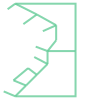

In [25]:
multi_line

In [40]:
import json
from shapely.geometry import MultiLineString, Polygon, MultiPolygon
from shapely.ops import unary_union

# Load the GeoJSON file
file_path = "/home/tobfer/Downloads/ouput_metarea.geojson"
with open(file_path) as file:
    geojson_data = json.load(file)

# Create a list to store the polygons
all_polygons = []

# Iterate over all features in the GeoJSON
for feature in geojson_data["features"]:
    # Extract the geometry
    geometry = shape(feature["geometry"])

    # Ensure the geometry is a MultiLineString
    if isinstance(geometry, MultiLineString):
        # Remove duplicate lines by converting to a set
        unique_lines = set(geometry.geoms)

        # Iterate over the unique geometries (each LineString) in the MultiLineString
        for line in unique_lines:
            # Buffer the line slightly to create a polygon
            polygon = line.buffer(0.01)  # Adjust the buffer distance as needed

            # Check if the result is a polygon (it could be a MultiPolygon)
            if isinstance(polygon, Polygon):
                all_polygons.append(polygon)
            elif isinstance(polygon, MultiPolygon):
                all_polygons.extend(polygon)

# Union the polygons to merge overlapping ones
merged_polygons = unary_union(all_polygons)

# Convert the merged polygons to a GeoDataFrame
gdf = gpd.GeoDataFrame(geometry=[merged_polygons], crs="EPSG:4326")

# Save the result to a new GeoJSON file
output_path = "/home/tobfer/Downloads/output_polygons.geojson"
gdf.to_file(output_path, driver="GeoJSON")

print(f"GeoJSON saved to {output_path}")

GeoJSON saved to /home/tobfer/Downloads/output_polygons.geojson


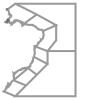

In [38]:
gdf.iloc[0].geometry

In [5]:
import json
from pathlib import Path
from django.contrib.gis.geos import GEOSGeometry
from django.contrib.gis.gdal import SpatialReference, CoordTransform
from shapely.geometry import shape, mapping


def close_ring(geom):
    """Ensure that polygon rings are closed."""
    shapely_geom = shape(geom)  # Convert to Shapely
    if shapely_geom.is_valid and not shapely_geom.exterior.is_closed:
        shapely_geom = shapely_geom.buffer(0)  # Attempt to auto-fix
    return mapping(shapely_geom)  # Convert back to GeoJSON


def generate_fixture(geojson_dir, output_file):
    fixture = []
    geojson_files = sorted(Path(geojson_dir).glob("*.json"))
    source_srs = SpatialReference(4326)
    target_srs = SpatialReference(3857)
    transform = CoordTransform(source_srs, target_srs)

    for pk, geojson_file in enumerate(geojson_files, start=1):
        name = geojson_file.stem.upper()  # Extract name from filename
        with open(geojson_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        try:
            # Fix invalid geometries
            fixed_geom = close_ring(data["features"][0]["geometry"])
            geom = GEOSGeometry(json.dumps(fixed_geom))  # Convert to Django GEOS format

            # Transform geometry to EPSG:3857
            geom.srid = 4326  # Ensure it's set to WGS 84
            geom.transform(transform)  # Convert to Web Mercator (EPSG:3857)

            fixture.append(
                {
                    "model": "weather_warnings.metareapolygon",
                    "pk": pk,
                    "fields": {
                        "name": name,
                        "geometry": geom.json,  # Store geometry in GeoJSON format
                    },
                }
            )
        except Exception as e:
            print(f"Skipping {geojson_file} due to error: {e}")

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(fixture, f, indent=2)

    print(f"Fixture saved to {output_file}")


# Example usage
geojson_dir = "/mnt/soutobias/code/oceanoslive/metarea"

generate_fixture(geojson_dir, "output_fixture10.json")

Fixture saved to output_fixture10.json


In [8]:
import json

file_path = (
    "../../../../oceanobs_api/apps/weather_warnings/fixtures/metarea_polygon.json"
)

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

for obj in data:
    geom = obj["fields"]["geometry"]
    coordinates = json.loads(geom)["coordinates"]

    for ring in coordinates:  # Iterate over polygon rings
        for point in ring:
            lon, lat = point  # Assuming it's in (lon, lat) format
            if not (-180 <= lon <= 180 and -90 <= lat <= 90):
                print(f"Invalid point found: {point}")

Invalid point found: [-5434939.119822256, -3324133.7496255115]
Invalid point found: [-4786738.104110763, -3632749.143384426]
Invalid point found: [-5343335.558077131, -4300621.372044271]
Invalid point found: [-5940165.318807556, -3993326.006752096]
Invalid point found: [-5891122.0308630355, -3948778.8617649255]
Invalid point found: [-5873538.117156187, -3930718.5596746434]
Invalid point found: [-5861221.224278376, -3913607.990222517]
Invalid point found: [-5845219.047476844, -3878762.865111165]
Invalid point found: [-5826645.868763923, -3821173.567231391]
Invalid point found: [-5819182.897042285, -3805880.7019930524]
Invalid point found: [-5809784.879484591, -3792329.185914597]
Invalid point found: [-5802794.798177943, -3785353.70215593]
Invalid point found: [-5807213.877573202, -3774930.162374478]
Invalid point found: [-5809937.07410091, -3759055.5042551556]
Invalid point found: [-5810159.930503377, -3748296.234722596]
Invalid point found: [-5801952.292266177, -3723330.6673919787]
Inv

In [52]:
geojson_dir = (
    "/mnt/soutobias/code/oceanoslive/oceanobs_api/apps/weather_warnings/fixtures/"
)
geojson_files = sorted(Path(geojson_dir).glob("*.geojson"))

In [53]:
geojson_files

[]

In [42]:
# Create a list to store the polygons
all_polygons = []

# Iterate over all features in the GeoJSON
for feature in geojson_data["features"]:
    # Extract the geometry
    geometry = shape(feature["geometry"])

    # Ensure the geometry is a MultiLineString
    if isinstance(geometry, MultiLineString):
        # Remove duplicate lines by converting to a set
        unique_lines = set(geometry.geoms)

        # Iterate over the unique geometries (each LineString) in the MultiLineString
        for line in unique_lines:
            # Buffer the line slightly to create a polygon
            polygon = line.buffer(0.01)  # Adjust the buffer distance as needed

            # Check if the result is a polygon (it could be a MultiPolygon)
            if isinstance(polygon, Polygon):
                all_polygons.append(polygon)
            elif isinstance(polygon, MultiPolygon):
                all_polygons.extend(
                    polygon.geoms
                )  # Use .geoms to iterate over individual polygons

# Union the polygons to merge overlapping ones
merged_polygons = unary_union(all_polygons)

# Check if merged_polygons is a MultiPolygon (could be a single polygon or multiple polygons)
if isinstance(merged_polygons, MultiPolygon):
    # Save each individual polygon in the MultiPolygon as a separate GeoJSON
    for idx, polygon in enumerate(merged_polygons.geoms):  # Use .geoms to iterate
        gdf = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")
        output_path = f"/home/tobfer/Downloads/output_polygon_{idx + 1}.geojson"
        gdf.to_file(output_path, driver="GeoJSON")
        print(f"GeoJSON saved to {output_path}")
else:
    # If it's a single polygon, save it as one file
    gdf = gpd.GeoDataFrame(geometry=[merged_polygons], crs="EPSG:4326")
    output_path = "/home/tobfer/Downloads/output_polygon_1.geojson"
    gdf.to_file(output_path, driver="GeoJSON")
    print(f"GeoJSON saved to {output_path}")

GeoJSON saved to /home/tobfer/Downloads/output_polygon_1.geojson
GeoJSON saved to /home/tobfer/Downloads/output_polygon_2.geojson
GeoJSON saved to /home/tobfer/Downloads/output_polygon_3.geojson


In [45]:
# Load the GeoJSON file
file_path = "/home/tobfer/Downloads/output_polygon_10.geojson"
with open(file_path) as file:
    geojson_data = json.load(file)

In [47]:
geometry = shape(feature["geometry"])

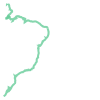

In [48]:
geometry

In [20]:
gdf = gpd.GeoDataFrame(geometry=geojson_data, crs="EPSG:4326")

TypeError: Passing a dict as an indexer is not supported. Use a list instead.

In [6]:
data = json.loads(geojson)
polygon = shape(data["features"][0]["geometry"])
# polygon = make_valid(polygon)
minx, miny, maxx, maxy = polygon.bounds

In [7]:
minx

-53.36141296081538

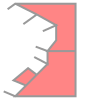

In [8]:
polygon

In [3]:
import cartopy.feature as cfeature
import geopandas as gpd
import shapely.geometry as sg

# Define the bounding box for the Brazilian coast you want to extract
min_lon, min_lat = -53.3667, -33.7333
max_lon, max_lat = -51.55, 4.4333

# Load Cartopy's Natural Earth coastline
coastline_feature = cfeature.NaturalEarthFeature("physical", "coastline", scale="50m")

# Convert coastline to GeoDataFrame
coastline_shapes = []
for geom in coastline_feature.geometries():
    coastline_shapes.append(geom)

gdf = gpd.GeoDataFrame(geometry=coastline_shapes, crs="EPSG:4326")

# Filter the coastline to only include parts within the bounding box
brazil_coast = gdf[gdf.intersects(sg.box(min_lon, min_lat, max_lon, max_lat))]

# Merge into a single LineString (if needed)
brazil_coast_line = brazil_coast.union_all()

In [4]:
brazil_coast_gdf = gpd.GeoDataFrame(geometry=[brazil_coast_line], crs="EPSG:4326")

# Save to GeoJSON file
brazil_coast_gdf.to_file("brazil_coastline.geojson", driver="GeoJSON")

In [191]:
coastline_shapes

[<LINESTRING (59.916 -67.4, 59.679 -67.394, 59.657 -67.397, 59.646 -67.406, 5...>,
 <LINESTRING (-51.731 -82.063, -52.187 -82.112, -52.643 -82.16, -52.934 -82.1...>,
 <LINESTRING (166.137 -50.864, 166.107 -50.852, 166.096 -50.851, 166.09 -50.8...>,
 <LINESTRING (-56.668 -36.736, -56.665 -36.851, -56.669 -36.894, -56.686 -36....>,
 <LINESTRING (-51.079 3.492, -51.096 3.449, -51.093 3.376, -51.036 3.229, -51...>,
 <LINESTRING (-80.759 -33.767, -80.749 -33.774, -80.732 -33.775, -80.715 -33....>,
 <LINESTRING (-78.789 -33.609, -78.807 -33.61, -78.816 -33.609, -78.82 -33.60...>,
 <LINESTRING (-109.232 -27.092, -109.242 -27.091, -109.252 -27.093, -109.261 ...>,
 <LINESTRING (163.985 -20.048, 163.975 -20.035, 163.967 -20.008, 163.958 -20,...>,
 <LINESTRING (128.159 -15.09, 128.158 -15.087, 128.152 -15.052, 128.131 -15.0...>,
 <LINESTRING (128.416 -14.956, 128.409 -14.945, 128.385 -14.892, 128.372 -14....>,
 <LINESTRING (129.632 -14.847, 129.626 -14.835, 129.616 -14.825, 129.606 -14....>,
 <LI

In [182]:
grid_size_x = (maxx - minx) / 3
grid_size_y = (maxy - miny) / 3

In [184]:
# Create grid polygons
sub_polygons = []
for i in range(3):
    for j in range(3):
        cell = box(
            minx + i * grid_size_x,
            miny + j * grid_size_y,
            minx + (i + 1) * grid_size_x,
            miny + (j + 1) * grid_size_y,
        )
        intersection = polygon.intersection(cell)
        if not intersection.is_empty:
            sub_polygons.append(intersection)

# Convert back to GeoJSON
gdf = gpd.GeoDataFrame(geometry=sub_polygons)

In [185]:
gdf

,geometry
0,GEOMETRYCOLLECTION (LINESTRING (-53.36667 -33....
1,GEOMETRYCOLLECTION (LINESTRING (-42.24444 -1.0...
2,"POLYGON ((-42 -23.01667, -38 -26, -33.66667 -2..."
3,"GEOMETRYCOLLECTION (LINESTRING (-33 -21, -39.2..."
4,GEOMETRYCOLLECTION (LINESTRING (-31.12222 -3.9...
5,"POLYGON ((-20 -21.66667, -20 -36, -31.12222 -3..."
6,"POLYGON ((-31.12222 -12.65278, -29 -10, -29 -7..."
7,"GEOMETRYCOLLECTION (LINESTRING (-29 -3, -31.12..."


In [174]:
print("Is polygon valid?", polygon.is_valid)

Is polygon valid? False


In [177]:
polygon = make_valid(polygon)

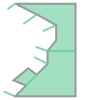

In [178]:
polygon